# Customer Lifetime Value Prediction
This notebook demonstrates CLV prediction using various supervised regression models.

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from datetime import datetime

In [3]:
# Load dataset
df = pd.read_csv('synthetic_customer_transactions.csv')
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y')
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], format='%d-%m-%Y')

In [4]:
# Define cutoff date
cutoff_date = pd.to_datetime('2022-01-01')
historical = df[df['Transaction_Date'] < cutoff_date]
future = df[df['Transaction_Date'] >= cutoff_date]

In [5]:
# Aggregate features
features = historical.groupby('CustomerID').agg({
    'Transaction_Date': [
        lambda x: (cutoff_date - x.max()).days,
        lambda x: x.count(),
        lambda x: (cutoff_date - x.min()).days
    ],
    'TotalPrice': 'sum'
})
features.columns = ['Recency', 'Frequency', 'Tenure', 'Monetary']
features = features.reset_index()

In [6]:
# Create target variable
target = future.groupby('CustomerID')['TotalPrice'].sum().reset_index()
target.columns = ['CustomerID', 'CLV']
data = pd.merge(features, target, on='CustomerID', how='inner')

In [10]:
data.head(15)

,CustomerID,Recency,Frequency,Tenure,Monetary,CLV
0,CUST_00000,196,3,249,1460.84,2170.28
1,CUST_00001,48,4,278,2378.22,3930.03
2,CUST_00002,98,6,341,3223.78,5616.21
3,CUST_00003,50,12,294,6276.78,10812.55
4,CUST_00004,146,3,353,2003.89,6135.09
5,CUST_00005,26,9,358,4897.95,6019.99
6,CUST_00006,283,2,336,839.56,3568.10
7,CUST_00007,126,6,356,2422.23,5494.43
8,CUST_00008,139,2,220,508.18,4232.25
9,CUST_00009,13,5,299,3683.08,5179.77


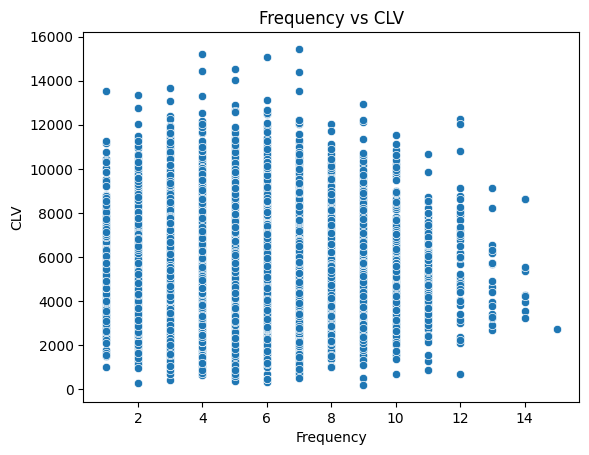

In [7]:
# EDA: Hypothesis testing example
sns.scatterplot(x='Frequency', y='CLV', data=data)
plt.title('Frequency vs CLV')
plt.show()

In [9]:
# Model training and evaluation
X = data[['Recency', 'Frequency', 'Tenure', 'Monetary']]
y = data['CLV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(),
    'LightGBM': lgb.LGBMRegressor()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }
results_df = pd.DataFrame(results).T
results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 7959, number of used features: 4
[LightGBM] [Info] Start training from score 5454.108009


,MAE,RMSE,R2
LinearRegression,1644.588295,2083.783279,0.000858
DecisionTree,2448.721407,3074.854826,-1.175561
RandomForest,1724.722091,2185.591545,-0.099158
XGBoost,1753.491570,2233.560263,-0.147935
LightGBM,1676.059743,2131.585577,-0.045508
